# 02 — Player EDA

Exploratory analysis of `data/interim/players_clean.parquet`.

Sections:
1. Overview
2. Zero-Activity Rows
3. Passing Stats (QB)
4. Rushing Stats (RB)
5. Receiving Stats (WR / TE)
6. EPA by Position
7. Season Trends
8. Top Performers (Sanity Check)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

DATA_PATH = Path("../data/interim/players_clean.parquet")
players = pd.read_parquet(DATA_PATH)

print(f"Shape:   {players.shape}")
print(f"Seasons: {sorted(players['season'].unique())}")
print(f"Columns: {players.columns.tolist()}")
players.head()

Shape:   (38212, 25)
Seasons: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Columns: ['player_id', 'player_name', 'position_group', 'recent_team', 'season', 'week', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'interceptions', 'passing_air_yards', 'passing_epa', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_epa', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_air_yards', 'receiving_epa', 'target_share', 'air_yards_share']


,player_id,player_name,position_group,recent_team,season,week,completions,attempts,passing_yards,passing_tds,interceptions,passing_air_yards,passing_epa,carries,rushing_yards,rushing_tds,rushing_epa,receptions,targets,receiving_yards,receiving_tds,receiving_air_yards,receiving_epa,target_share,air_yards_share
0,00-0019596,T.Brady,QB,NE,2018,1,26,39,277.000,3,1.000,320.000,8.183,1,2.000,0,1.838,0,0,0.000,0,0.000,NaN,NaN,NaN
1,00-0020531,D.Brees,QB,NO,2018,1,37,45,439.000,3,0.000,348.000,22.274,0,0.000,0,NaN,0,0,0.000,0,0.000,NaN,NaN,NaN
2,00-0021547,A.Gates,TE,LAC,2018,1,0,0,0.000,0,0.000,0.000,NaN,0,0.000,0,NaN,2,3,16.000,0,27.000,0.905,0.060,0.056
3,00-0022803,E.Manning,QB,NYG,2018,1,23,37,224.000,0,1.000,249.000,-11.798,1,2.000,0,-0.408,0,0,0.000,0,0.000,NaN,NaN,NaN
4,00-0022921,L.Fitzgerald,WR,ARI,2018,1,0,0,0.000,0,0.000,0.000,NaN,0,0.000,0,NaN,7,10,76.000,0,90.000,2.104,0.294,0.433


In [ ]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38212 entries, 0 to 38211
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    38212 non-null  string 
 1   player_name                  38212 non-null  string 
 2   position                     38212 non-null  string 
 3   position_group               38212 non-null  string 
 4   recent_team                  38212 non-null  string 
 5   season                       38212 non-null  int64  
 6   week                         38212 non-null  Int64  
 7   season_type                  38212 non-null  string 
 8   opponent_team                38212 non-null  string 
 9   completions                  38212 non-null  Int64  
 10  attempts                     38212 non-null  Int64  
 11  passing_yards                38212 non-null  float32
 12  passing_tds                  38212 non-null  Int64  
 13  interceptions   

## 1. Overview

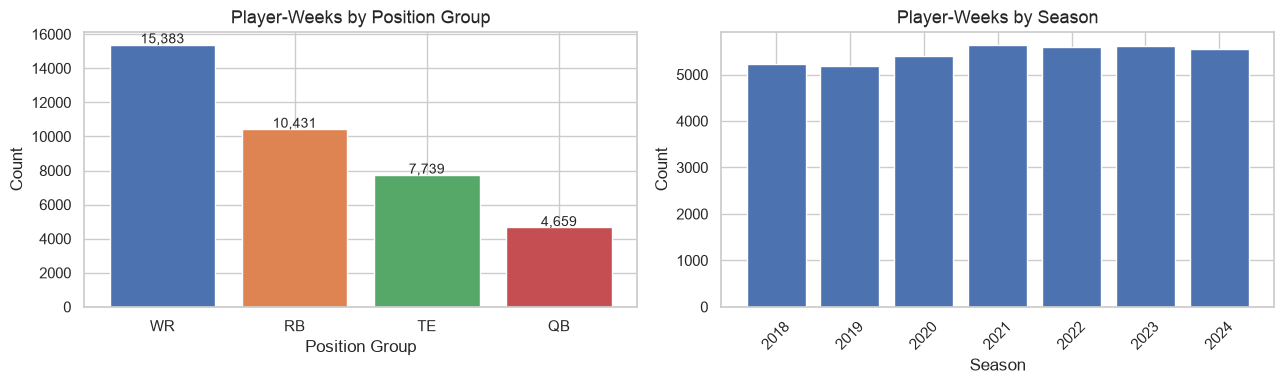

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pos_counts = players["position_group"].value_counts()
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = axes[0].bar(pos_counts.index, pos_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Player-Weeks by Position Group", fontsize=13)
axes[0].set_xlabel("Position Group")
axes[0].set_ylabel("Count")
for bar, v in zip(bars, pos_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 80, f"{v:,}", ha="center", fontsize=10)

season_counts = players["season"].value_counts().sort_index()
axes[1].bar(season_counts.index.astype(str), season_counts.values, color="#4C72B0", edgecolor="white")
axes[1].set_title("Player-Weeks by Season", fontsize=13)
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 2. Zero-Activity Rows

Some rows represent players who were on a roster but had no carries, receptions, or attempts that week. These are real but uninformative for play-level modeling — worth understanding how many exist and where they concentrate.

In [10]:
zero = players[(players["carries"] == 0) & (players["receptions"] == 0) & (players["attempts"] == 0)]
active = players.drop(zero.index)

print(f"Total rows:         {len(players):>6,}")
print(f"Active rows:        {len(active):>6,}  ({len(active)/len(players)*100:.1f}%)")
print(f"Zero-activity rows: {len(zero):>6,}  ({len(zero)/len(players)*100:.1f}%)")
print()
print("Zero-activity breakdown by position:")
print(zero["position_group"].value_counts().to_string())

Total rows:         38,212
Active rows:        35,723  (93.5%)
Zero-activity rows:  2,489  (6.5%)

Zero-activity breakdown by position:
WR    1418
TE     864
RB     195
QB      12


## 3. Passing Stats (QB)

Active QB game-weeks: 4,426


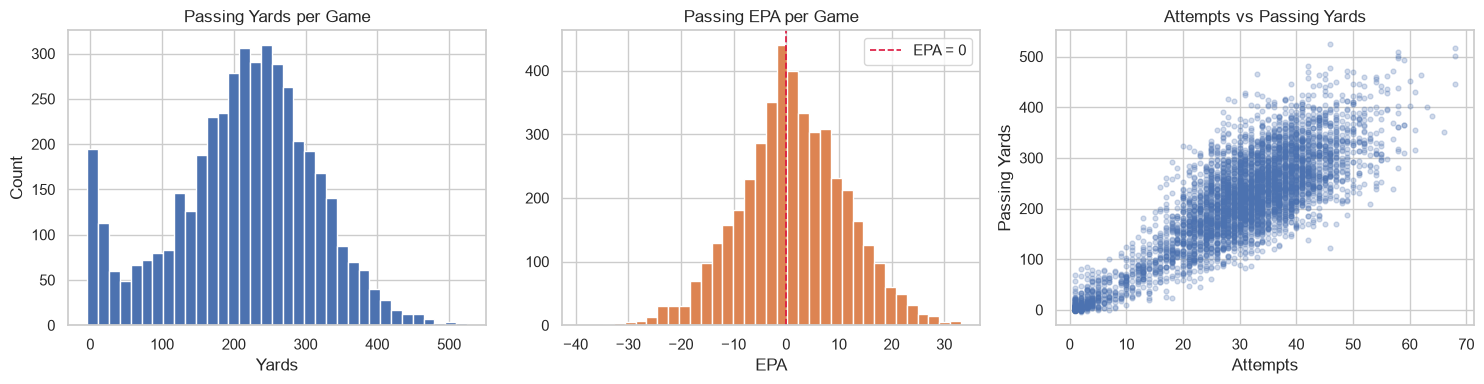

In [11]:
qbs = players[(players["position_group"] == "QB") & (players["attempts"] > 0)].copy()
print(f"Active QB game-weeks: {len(qbs):,}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(qbs["passing_yards"].dropna(), bins=35, color="#4C72B0", edgecolor="white")
axes[0].set_title("Passing Yards per Game")
axes[0].set_xlabel("Yards")
axes[0].set_ylabel("Count")

axes[1].hist(qbs["passing_epa"].dropna(), bins=35, color="#DD8452", edgecolor="white")
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.2, label="EPA = 0")
axes[1].set_title("Passing EPA per Game")
axes[1].set_xlabel("EPA")
axes[1].legend()

axes[2].scatter(qbs["attempts"], qbs["passing_yards"], alpha=0.25, color="#4C72B0", s=12)
axes[2].set_title("Attempts vs Passing Yards")
axes[2].set_xlabel("Attempts")
axes[2].set_ylabel("Passing Yards")

plt.tight_layout()
plt.show()

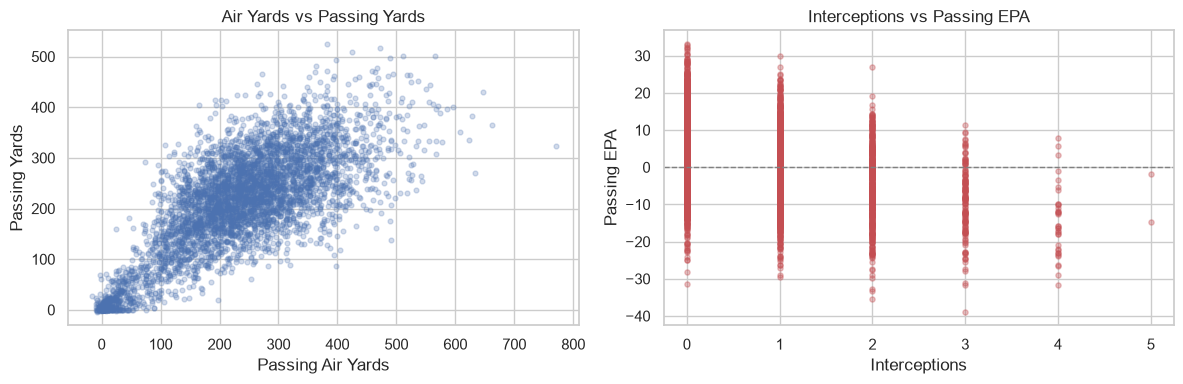

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(qbs["passing_air_yards"], qbs["passing_yards"], alpha=0.25, color="#4C72B0", s=12)
axes[0].set_title("Air Yards vs Passing Yards")
axes[0].set_xlabel("Passing Air Yards")
axes[0].set_ylabel("Passing Yards")

axes[1].scatter(qbs["interceptions"], qbs["passing_epa"], alpha=0.35, color="#C44E52", s=14)
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Interceptions vs Passing EPA")
axes[1].set_xlabel("Interceptions")
axes[1].set_ylabel("Passing EPA")

plt.tight_layout()
plt.show()

## 4. Rushing Stats (RB)

Active RB game-weeks: 9,429


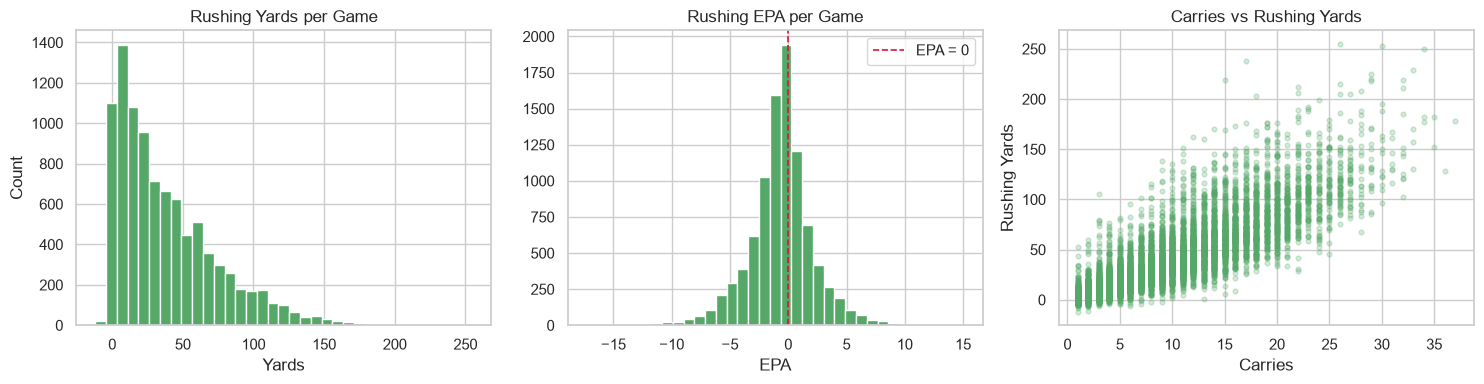

In [13]:
rbs = players[(players["position_group"] == "RB") & (players["carries"] > 0)].copy()
print(f"Active RB game-weeks: {len(rbs):,}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rbs["rushing_yards"].dropna(), bins=35, color="#55A868", edgecolor="white")
axes[0].set_title("Rushing Yards per Game")
axes[0].set_xlabel("Yards")
axes[0].set_ylabel("Count")

axes[1].hist(rbs["rushing_epa"].dropna(), bins=35, color="#55A868", edgecolor="white")
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.2, label="EPA = 0")
axes[1].set_title("Rushing EPA per Game")
axes[1].set_xlabel("EPA")
axes[1].legend()

axes[2].scatter(rbs["carries"], rbs["rushing_yards"], alpha=0.25, color="#55A868", s=12)
axes[2].set_title("Carries vs Rushing Yards")
axes[2].set_xlabel("Carries")
axes[2].set_ylabel("Rushing Yards")

plt.tight_layout()
plt.show()

## 5. Receiving Stats (WR / TE)

Active WR/TE game-weeks: 22,839


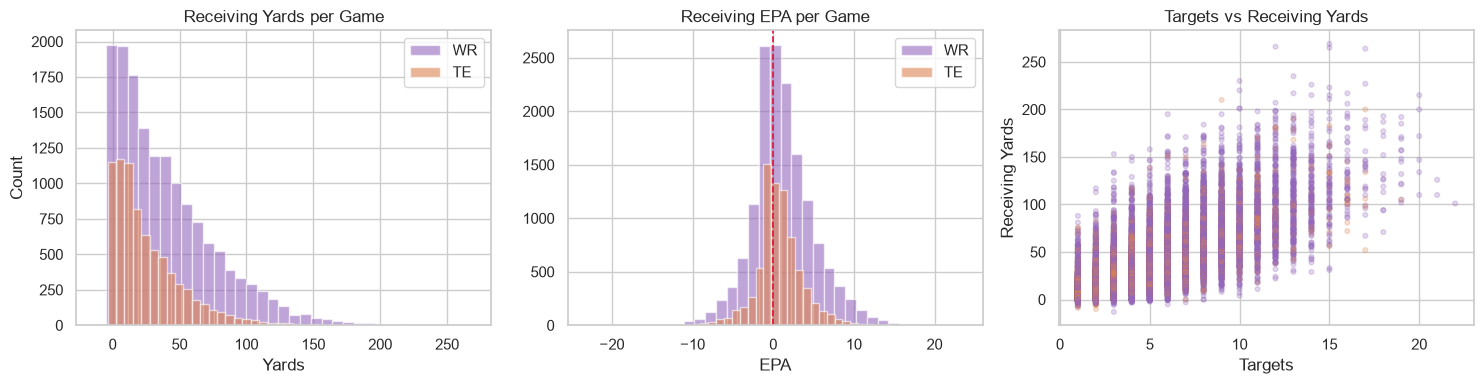

In [14]:
receivers = players[
    players["position_group"].isin(["WR", "TE"]) & (players["targets"] > 0)
].copy()
print(f"Active WR/TE game-weeks: {len(receivers):,}")

pos_colors = {"WR": "#9467BD", "TE": "#DD8452"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for pos, color in pos_colors.items():
    subset = receivers[receivers["position_group"] == pos]
    axes[0].hist(subset["receiving_yards"].dropna(), bins=35, alpha=0.6, label=pos, color=color, edgecolor="white")
    axes[1].hist(subset["receiving_epa"].dropna(), bins=35, alpha=0.6, label=pos, color=color, edgecolor="white")

axes[0].set_title("Receiving Yards per Game")
axes[0].set_xlabel("Yards")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[1].set_title("Receiving EPA per Game")
axes[1].set_xlabel("EPA")
axes[1].legend()

axes[2].scatter(
    receivers["targets"], receivers["receiving_yards"],
    c=receivers["position_group"].map(pos_colors),
    alpha=0.25, s=12,
)
axes[2].set_title("Targets vs Receiving Yards")
axes[2].set_xlabel("Targets")
axes[2].set_ylabel("Receiving Yards")

plt.tight_layout()
plt.show()

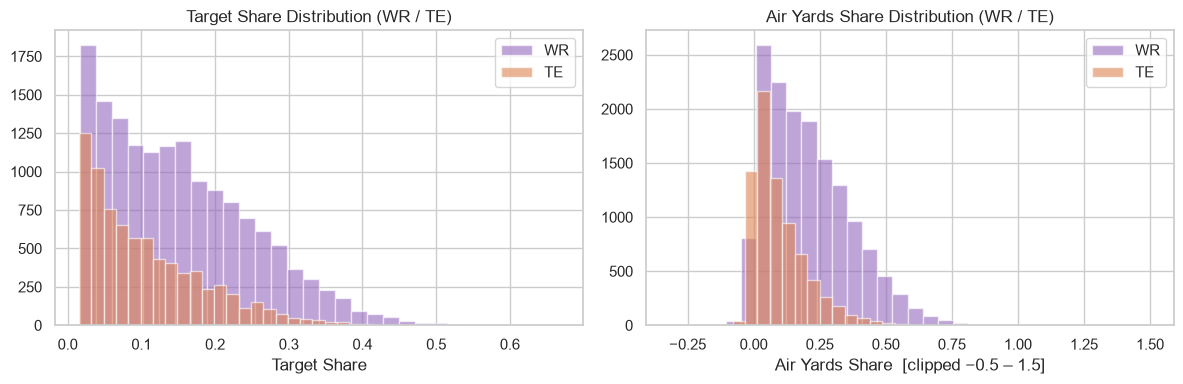

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for pos, color in pos_colors.items():
    subset = receivers[receivers["position_group"] == pos]
    axes[0].hist(subset["target_share"].dropna(), bins=30, alpha=0.6, label=pos, color=color, edgecolor="white")
    axes[1].hist(
        subset["air_yards_share"].dropna().clip(-0.5, 1.5),
        bins=30, alpha=0.6, label=pos, color=color, edgecolor="white",
    )

axes[0].set_title("Target Share Distribution (WR / TE)")
axes[0].set_xlabel("Target Share")
axes[0].legend()

axes[1].set_title("Air Yards Share Distribution (WR / TE)")
axes[1].set_xlabel("Air Yards Share  [clipped −0.5 – 1.5]")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. EPA by Position

Boxplots (outliers hidden) show the typical EPA range for active players in each phase. The red dashed line marks EPA = 0 — the break-even point against expected value.

In [ ]:
epa_configs = [
    ("passing_epa",   ["QB"],           ["QB"],           ["#4C72B0"],           "Passing EPA"),
    ("rushing_epa",   ["RB", "QB"],      ["RB", "QB"],     ["#55A868", "#4C72B0"], "Rushing EPA"),
    ("receiving_epa", ["WR", "TE", "RB"],["WR", "TE", "RB"],["#9467BD","#DD8452","#55A868"], "Receiving EPA"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, positions, labels, colors, title) in zip(axes, epa_configs):
    data  = [players[(players["position_group"] == p) & players[col].notna()][col].values for p in positions]
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.5)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)
    ax.axhline(0, color="crimson", linestyle="--", linewidth=1.2, label="EPA = 0")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("EPA")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Season Trends

Average yards per active game-week, by position and season. Filters to players with at least one relevant volume stat so season-long inactives don't suppress the mean.

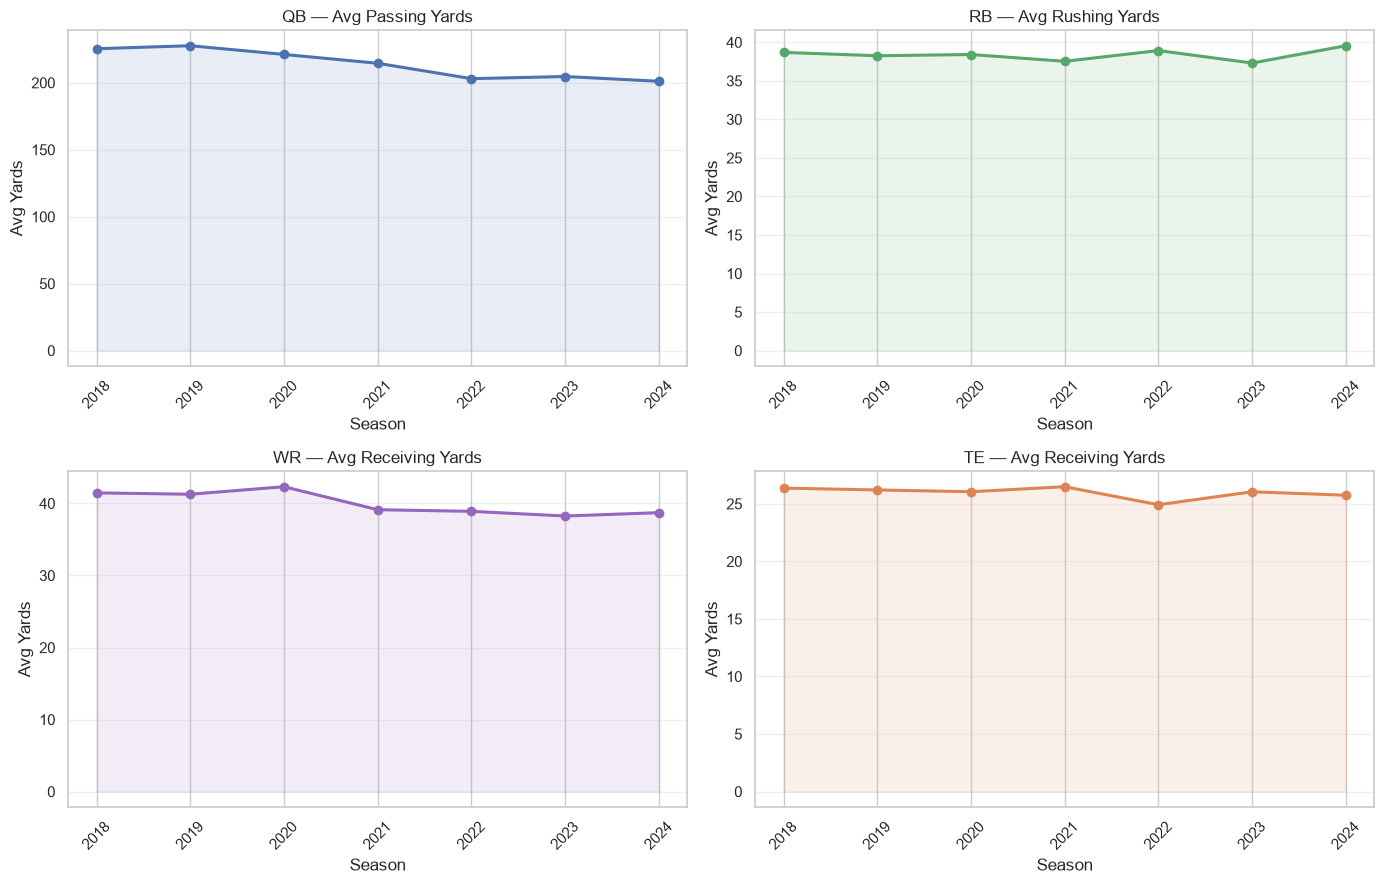

In [16]:
trend_configs = [
    ("QB",  "passing_yards",  "attempts", "QB — Avg Passing Yards",   "#4C72B0"),
    ("RB",  "rushing_yards",  "carries",  "RB — Avg Rushing Yards",   "#55A868"),
    ("WR",  "receiving_yards","targets",  "WR — Avg Receiving Yards", "#9467BD"),
    ("TE",  "receiving_yards","targets",  "TE — Avg Receiving Yards", "#DD8452"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (pos, yard_col, vol_col, title, color) in zip(axes.flat, trend_configs):
    subset = players[(players["position_group"] == pos) & (players[vol_col] > 0)]
    trend = subset.groupby("season")[yard_col].mean()
    ax.plot(trend.index, trend.values, marker="o", color=color, linewidth=2.2, markersize=6)
    ax.fill_between(trend.index, trend.values, alpha=0.12, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Season")
    ax.set_ylabel("Avg Yards")
    ax.set_xticks(trend.index)
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Top Performers (Sanity Check)

Best single-game performances from 2023 — confirms the data contains expected player names and reasonable values.

In [19]:
season = 2023
s = players[players["season"] == season]

top_configs = [
    ("QB",  "passing_yards",  ["player_name", "recent_team", "week", "attempts", "passing_yards", "passing_tds", "passing_epa"]),
    ("RB",  "rushing_yards",  ["player_name", "recent_team", "week", "carries",  "rushing_yards",  "rushing_tds",  "rushing_epa"]),
    ("WR",  "receiving_yards",["player_name", "recent_team", "week", "targets",  "receptions", "receiving_yards", "receiving_tds", "receiving_epa"]),
    ("TE",  "receiving_yards",["player_name", "recent_team", "week", "targets",  "receptions", "receiving_yards", "receiving_tds", "receiving_epa"]),
]

for pos, sort_col, cols in top_configs:
    print(f"── Top 5 {pos}s — {sort_col.replace('_', ' ').title()} ({season}) ──")
    top = s[s["position_group"] == pos].nlargest(5, sort_col)[cols]
    print(top.to_string(index=False))
    print()

── Top 5 QBs — Passing Yards (2023) ──
 player_name recent_team  week  attempts  passing_yards  passing_tds  passing_epa
    C.Stroud         HOU     9        42        470.000            5       28.419
T.Tagovailoa         MIA     1        45        466.000            3       27.078
   P.Mahomes          KC     7        42        424.000            4       22.320
   N.Mullens         MIN    16        36        411.000            2        5.691
   J.Herbert         LAC     3        47        405.000            3       21.502

── Top 5 RBs — Rushing Yards (2023) ──
player_name recent_team  week  carries  rushing_yards  rushing_tds  rushing_epa
   D.Achane         MIA     3       18        203.000            2       12.527
   J.Taylor         IND    18       30        188.000            1        1.580
     J.Cook         BUF    15       25        179.000            1        8.341
     B.Hall         NYJ    18       37        178.000            1       -2.534
     B.Hall         NYJ     5